**TARGET ==>**

In [2]:
print(
"""
05  Weight ↔ Mission Iteration
        ↓
06  Raymer Geometry Sizing
        ↓
07  Aerodynamic Model
        ↓
08  Propulsion Model
        ↓
09  Performance
        ↓
10  Stability
        ↓
11  Full Mission
        ↓
12  Large Design Dataset
        ↓
13  EDA
        ↓
14  ML / Surrogate
        ↓
15  UQ
        ↓
16  Optimization
        ↓
17  Decision
        ↓
       TBM-X
       """)


05  Weight ↔ Mission Iteration
        ↓
06  Raymer Geometry Sizing
        ↓
07  Aerodynamic Model
        ↓
08  Propulsion Model
        ↓
09  Performance
        ↓
10  Stability
        ↓
11  Full Mission
        ↓
12  Large Design Dataset
        ↓
13  EDA
        ↓
14  ML / Surrogate
        ↓
15  UQ
        ↓
16  Optimization
        ↓
17  Decision
        ↓
       TBM-X
       


**TARGET OF NOTEBBOOK :: 05_RAYMER_WEIGHT_MISSION_ITERATION.ipynb**

In [3]:
print(
"""
                 INITIAL MTOW
                      │
                      ▼
              ┌───────────────┐
              │ Mission Model │
              │ 03 + 04       │
              └───────┬───────┘
                      │
                      ▼
                Fuel Fraction
                      │
                      ▼
              Weight Breakdown
                      │
                      ▼
               New MTOW
                      │
                      └───────────┐
                                  │
                         convergence?
                                  │
                    ┌─────────────┴─────────────┐
                    │                           │
                   YES                          NO
                    │                           │
                    ▼                           ▼
              FINAL DESIGN              NEXT ITERATION
              """)


                 INITIAL MTOW
                      │
                      ▼
              ┌───────────────┐
              │ Mission Model │
              │ 03 + 04       │
              └───────┬───────┘
                      │
                      ▼
                Fuel Fraction
                      │
                      ▼
              Weight Breakdown
                      │
                      ▼
               New MTOW
                      │
                      └───────────┐
                                  │
                         convergence?
                                  │
                    ┌─────────────┴─────────────┐
                    │                           │
                   YES                          NO
                    │                           │
                    ▼                           ▼
              FINAL DESIGN              NEXT ITERATION
              


In [4]:
# ============================================================
# TBM-X — 05 RAYMER WEIGHT ↔ MISSION ITERATION
# ============================================================
#
# Amaç:
# Raymer ağırlık boyutlandırması ile mission analizini
# tek bir iteratif mühendislik döngüsünde birleştirmek.
#
# Temel döngü:
#
#       MTOW
#         ↓
#      Mission
#         ↓
#    Fuel Fraction
#         ↓
#   Weight Breakdown
#         ↓
#     New MTOW
#         ↓
#      Iterate
#
# Bu notebook:
# - 03_RAYMER_WEIGHT_SIZING notebook'undan ağırlık yaklaşımını
#   kullanır.
# - 04_RAYMER_MISSION_ANALYSIS notebook'undan mission/fuel
#   yaklaşımını kullanır.
# - MTOW ve mission fuel fraction arasında iteratif bağlantı kurar.
# - Convergence kontrolü yapar.
# - Benchmark verisini doğrulama amacıyla kullanır.
#
# ÖNEMLİ:
# Bu aşamadaki bazı aerodinamik ve propulsion parametreleri
# henüz engineering assumption'dır.
# Bunlar daha sonraki aşamalarda benchmark/data ile
# kalibre edilecektir..
#
# ============================================================

**DESIGN REQUIREMENTS**

In [6]:
# ============================================================
# TBM-X DESIGN REQUIREMENTS
# ============================================================

requirements = {
    "aircraft_category": "Single Engine Turboprop",
    
    "crew": 1,
    "passengers": 5,
    
    "range_km": 3000,
    "cruise_speed_kt": 300,
    "cruise_altitude_ft": 25000,
    
    "service_ceiling_ft": 31000,
    
    # Initial design estimate
    "initial_mtow_kg": 3400,
    
    "fuel_reserve_fraction": 0.10,
}

requirements

{'aircraft_category': 'Single Engine Turboprop',
 'crew': 1,
 'passengers': 5,
 'range_km': 3000,
 'cruise_speed_kt': 300,
 'cruise_altitude_ft': 25000,
 'service_ceiling_ft': 31000,
 'initial_mtow_kg': 3400,
 'fuel_reserve_fraction': 0.1}

**LIBRARIES**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**UNIT CONVERSIONS**

In [9]:

# ============================================================
# UNIT CONVERSIONS
# ============================================================

FT_TO_M = 0.3048
KT_TO_MS = 0.514444
KG_TO_LB = 2.20462262
LB_TO_KG = 1 / KG_TO_LB

requirements_converted = {
    "range_m": requirements["range_km"] * 1000,
    "cruise_speed_ms": requirements["cruise_speed_kt"] * KT_TO_MS,
    "cruise_altitude_m": requirements["cruise_altitude_ft"] * FT_TO_M,
    "service_ceiling_m": requirements["service_ceiling_ft"] * FT_TO_M,
    "initial_mtow_lb": requirements["initial_mtow_kg"] * KG_TO_LB,
}

pd.Series(requirements_converted)

range_m              3.000000e+06
cruise_speed_ms      1.543332e+02
cruise_altitude_m    7.620000e+03
service_ceiling_m    9.448800e+03
initial_mtow_lb      7.495717e+03
dtype: float64

**INITIAL AIRCRAFT GEOMETRY**

In [10]:
# ============================================================
# INITIAL AIRCRAFT GEOMETRY
# ============================================================

geometry = {
    # Benchmark-informed initial value
    "wing_area_m2": 18.0,
    
    # Initial aspect ratio estimate
    "aspect_ratio": 9.15,
}

geometry

{'wing_area_m2': 18.0, 'aspect_ratio': 9.15}

**PAYLOAD MODEL**

In [11]:
# ============================================================
# PAYLOAD MODEL
# ============================================================

crew_mass_kg = requirements["crew"] * 86.18
passenger_mass_kg = requirements["passengers"] * 86.18

# Initial baggage assumption:
# approximately 13.6 kg/person
baggage_mass_kg = (
    (requirements["crew"] + requirements["passengers"]) * 13.6
)

payload_mass_kg = (
    crew_mass_kg
    + passenger_mass_kg
    + baggage_mass_kg
)

payload_breakdown = pd.DataFrame({
    "Component": [
        "Crew",
        "Passengers",
        "Baggage",
        "Total Payload"
    ],
    "Mass_kg": [
        crew_mass_kg,
        passenger_mass_kg,
        baggage_mass_kg,
        payload_mass_kg
    ]
})

payload_breakdown

,Component,Mass_kg
0,Crew,86.18
1,Passengers,430.90
2,Baggage,81.60
3,Total Payload,598.68


**EMPTY WEIGHT FRACTION**

In [12]:
# ============================================================
# EMPTY WEIGHT FRACTION
# ============================================================
#
# NOT:
# Bu model şu aşamada geçici bir placeholder'dır.
#
# Daha sonra:
# - Raymer regression
# - benchmark data
# - TBM-X dataset
# kullanılarak geliştirilecektir.
#
# ============================================================

def estimate_empty_weight_fraction(
    mtow_lb,
    A=2.36,
    C=-0.18,
    K_vs=1.00
):
    """
    Estimate empty-weight fraction.

    Current status:
        TEMPORARY ENGINEERING MODEL

    This is NOT yet the final TBM-X empty-weight model.
    """

    empty_weight_fraction = (
        A * (mtow_lb ** C) * K_vs
    )

    return empty_weight_fraction

**MISSION SEGMENT MODEL**

In [13]:
# ============================================================
# MISSION SEGMENT WEIGHT FRACTIONS
# ============================================================
#
# Initial conceptual values.
# These will progressively be replaced by physics-based
# calculations.
# ============================================================

mission_segment_fractions = {
    "takeoff": 0.970,
    "climb": 0.985,
    "descent": 0.990,
    "landing": 0.995,
}

mission_segment_fractions

{'takeoff': 0.97, 'climb': 0.985, 'descent': 0.99, 'landing': 0.995}

**ISA ATMOSPHERE MODEL // via 04_RAYMER_MISSION_ANALYSIS** 

In [14]:
# ============================================================
# ISA ATMOSPHERE MODEL
# ============================================================

def isa_atmosphere(altitude_m):
    """
    Simplified ISA atmosphere model.

    Valid here for the troposphere region used by
    the initial TBM-X cruise analysis.
    """

    T0 = 288.15       # K
    P0 = 101325.0     # Pa
    lapse_rate = 0.0065
    R = 287.05        # J/(kg K)
    g = 9.80665        # m/s²

    T = T0 - lapse_rate * altitude_m

    P = P0 * (
        T / T0
    ) ** (
        g / (R * lapse_rate)
    )

    rho = P / (R * T)

    return T, P, rho

**CRUISE ATMOSPHERE**

In [15]:
# ============================================================
# CRUISE ATMOSPHERE
# ============================================================

cruise_altitude_m = requirements_converted["cruise_altitude_m"]

T_cruise, P_cruise, rho_cruise = isa_atmosphere(
    cruise_altitude_m
)

print(f"Temperature : {T_cruise:.2f} K")
print(f"Pressure    : {P_cruise:.1f} Pa")
print(f"Density     : {rho_cruise:.4f} kg/m³")

Temperature : 238.62 K
Pressure    : 37600.5 Pa
Density     : 0.5489 kg/m³


**AERODYNAMIC ASSUMPTIONS**

In [16]:
# ============================================================
# AERODYNAMIC MODEL
# ============================================================

aero = {
    "CD0": 0.025,
    "oswald_efficiency": 0.80,
    "aspect_ratio": geometry["aspect_ratio"],
}

# Induced drag factor
aero["k"] = 1 / (
    np.pi
    * aero["oswald_efficiency"]
    * aero["aspect_ratio"]
)

aero

{'CD0': 0.025,
 'oswald_efficiency': 0.8,
 'aspect_ratio': 9.15,
 'k': 0.043484957128933154}

**PARAMETER PROVENANCE**

In [17]:
# ============================================================
# PARAMETER PROVENANCE
# ============================================================

parameter_provenance = pd.DataFrame([
    {
        "Parameter": "CD0",
        "Value": aero["CD0"],
        "Origin": "Engineering Assumption",
        "Status": "Initial"
    },
    {
        "Parameter": "Oswald efficiency",
        "Value": aero["oswald_efficiency"],
        "Origin": "Engineering Assumption",
        "Status": "Initial"
    },
    {
        "Parameter": "Aspect ratio",
        "Value": aero["aspect_ratio"],
        "Origin": "Benchmark-informed assumption",
        "Status": "Initial"
    },
    {
        "Parameter": "Empty weight model",
        "Value": "A × W0^C",
        "Origin": "Raymer-style conceptual model",
        "Status": "Temporary"
    },
])

parameter_provenance

,Parameter,Value,Origin,Status
0,CD0,0.025,Engineering Assumption,Initial
1,Oswald efficiency,0.8,Engineering Assumption,Initial
2,Aspect ratio,9.15,Benchmark-informed assumption,Initial
3,Empty weight model,A × W0^C,Raymer-style conceptual model,Temporary


**PROPULSION ASSUMPTIONS**

In [18]:
# ============================================================
# PROPULSION MODEL
# ============================================================

propulsion = {
    # Initial engineering assumption
    "propeller_efficiency": 0.85,

    # kg fuel / kWh
    "BSFC_kg_kWh": 0.30,

    # Initial power assumption
    "shaft_power_kW": 650.0,
}

propulsion

{'propeller_efficiency': 0.85, 'BSFC_kg_kWh': 0.3, 'shaft_power_kW': 650.0}

**AERODYNAMIC CALCULATION function**

In [19]:
# ============================================================
# AERODYNAMIC CALCULATION
# ============================================================

def calculate_aerodynamics(
    mtow_kg,
    wing_area_m2,
    cruise_speed_ms,
    rho,
    cd0,
    k
):
    """
    Calculate cruise aerodynamic parameters.
    """

    g = 9.80665

    weight_N = mtow_kg * g

    q = 0.5 * rho * cruise_speed_ms**2

    CL = weight_N / (
        q * wing_area_m2
    )

    CD = cd0 + k * CL**2

    lift_to_drag = CL / CD

    drag_N = q * wing_area_m2 * CD

    return {
        "q_Pa": q,
        "CL": CL,
        "CD": CD,
        "L_D": lift_to_drag,
        "drag_N": drag_N,
    }

**CRUISE AERODYNAMIC TEST**

In [20]:
# ============================================================
# TEST AERODYNAMIC MODEL
# ============================================================

initial_aero = calculate_aerodynamics(
    mtow_kg=requirements["initial_mtow_kg"],
    wing_area_m2=geometry["wing_area_m2"],
    cruise_speed_ms=requirements_converted["cruise_speed_ms"],
    rho=rho_cruise,
    cd0=aero["CD0"],
    k=aero["k"],
)

pd.Series(initial_aero)

q_Pa      6537.597180
CL           0.283341
CD           0.028491
L_D          9.944899
drag_N    3352.734938
dtype: float64

**TURBOPROP BREGUET FUNCTION**

In [21]:
# ============================================================
# TURBOPROP BREGUET RANGE RELATION
# ============================================================

def calculate_cruise_fuel_fraction(
    range_m,
    bsfc_kg_kWh,
    propeller_efficiency,
    lift_to_drag
):
    """
    Calculate cruise fuel fraction using the
    turboprop Breguet range relation.

    cp is converted from kg/kWh to kg/(W·s).

    This is a conceptual model and assumes:
    - constant cruise conditions
    - constant L/D
    - constant propeller efficiency
    - constant BSFC
    """

    cp = bsfc_kg_kWh / 3_600_000

    exponent = (
        range_m * cp
        / (
            propeller_efficiency
            * lift_to_drag
        )
    )

    final_to_initial_weight = np.exp(
        -exponent
    )

    cruise_fuel_fraction = (
        1 - final_to_initial_weight
    )

    return cruise_fuel_fraction

**MISSION FUEL FRACTION FUNCTION**

In [22]:
# ============================================================
# COMPLETE MISSION FUEL FRACTION
# ============================================================

def calculate_mission_fuel_fraction(
    mtow_kg,
    wing_area_m2,
    cruise_speed_ms,
    rho,
    cd0,
    k,
    range_m,
    propeller_efficiency,
    bsfc_kg_kWh,
):
    """
    Calculate total mission fuel fraction.

    Returns:
        mission fuel fraction
        aerodynamic results
        cruise fuel fraction
    """

    aero_results = calculate_aerodynamics(
        mtow_kg=mtow_kg,
        wing_area_m2=wing_area_m2,
        cruise_speed_ms=cruise_speed_ms,
        rho=rho,
        cd0=cd0,
        k=k,
    )

    cruise_fuel_fraction = calculate_cruise_fuel_fraction(
        range_m=range_m,
        bsfc_kg_kWh=bsfc_kg_kWh,
        propeller_efficiency=propeller_efficiency,
        lift_to_drag=aero_results["L_D"],
    )

    # Weight fractions
    W_takeoff = mission_segment_fractions["takeoff"]
    W_climb = mission_segment_fractions["climb"]
    W_cruise = 1 - cruise_fuel_fraction
    W_descent = mission_segment_fractions["descent"]
    W_landing = mission_segment_fractions["landing"]

    mission_weight_fraction = (
        W_takeoff
        * W_climb
        * W_cruise
        * W_descent
        * W_landing
    )

    mission_fuel_fraction = (
        1 - mission_weight_fraction
    )

    return {
        "mission_fuel_fraction": mission_fuel_fraction,
        "cruise_fuel_fraction": cruise_fuel_fraction,
        **aero_results,
    }

**MISSION TEST**

In [23]:
# ============================================================
# TEST COMPLETE MISSION MODEL
# ============================================================

initial_mission = calculate_mission_fuel_fraction(
    mtow_kg=requirements["initial_mtow_kg"],
    wing_area_m2=geometry["wing_area_m2"],
    cruise_speed_ms=requirements_converted["cruise_speed_ms"],
    rho=rho_cruise,
    cd0=aero["CD0"],
    k=aero["k"],
    range_m=requirements_converted["range_m"],
    propeller_efficiency=propulsion["propeller_efficiency"],
    bsfc_kg_kWh=propulsion["BSFC_kg_kWh"],
)

pd.Series(initial_mission)

mission_fuel_fraction       0.086261
cruise_fuel_fraction        0.029142
q_Pa                     6537.597180
CL                          0.283341
CD                          0.028491
L_D                         9.944899
drag_N                   3352.734938
dtype: float64

**MTOW CALCULATION FUNCTION**

In [24]:
# ============================================================
# MTOW SIZING FUNCTION
# ============================================================

def calculate_mtow(
    payload_kg,
    empty_weight_fraction,
    mission_fuel_fraction
):
    """
    Calculate MTOW from payload, empty-weight fraction
    and mission fuel fraction.

    W0 = W_payload /
         (1 - We/W0 - Wf/W0)
    """

    denominator = (
        1
        - empty_weight_fraction
        - mission_fuel_fraction
    )

    if denominator <= 0:
        return np.nan

    mtow_kg = (
        payload_kg / denominator
    )

    return mtow_kg

**FIRST WEIGHT ↔ MISSION COUPLED CALCULATION**

In [25]:
# ============================================================
# FIRST WEIGHT ↔ MISSION COUPLED CALCULATION
# ============================================================

mtow_initial = requirements["initial_mtow_kg"]

empty_fraction_initial = estimate_empty_weight_fraction(
    mtow_initial * KG_TO_LB
)

mission_initial = calculate_mission_fuel_fraction(
    mtow_kg=mtow_initial,
    wing_area_m2=geometry["wing_area_m2"],
    cruise_speed_ms=requirements_converted["cruise_speed_ms"],
    rho=rho_cruise,
    cd0=aero["CD0"],
    k=aero["k"],
    range_m=requirements_converted["range_m"],
    propeller_efficiency=propulsion["propeller_efficiency"],
    bsfc_kg_kWh=propulsion["BSFC_kg_kWh"],
)

mtow_new = calculate_mtow(
    payload_kg=payload_mass_kg,
    empty_weight_fraction=empty_fraction_initial,
    mission_fuel_fraction=mission_initial[
        "mission_fuel_fraction"
    ],
)

print(f"Initial MTOW : {mtow_initial:.2f} kg")
print(f"New MTOW     : {mtow_new:.2f} kg")

Initial MTOW : 3400.00 kg
New MTOW     : 1360.32 kg


**ITERATION SETTING**

In [26]:
# ============================================================
# ITERATION CONTROL
# ============================================================

MAX_ITERATIONS = 100
TOLERANCE = 1e-4

# Relative relaxation factor.
#
# 1.0  -> full update
# <1.0 -> smoother convergence
#
# Start with full update.
RELAXATION_FACTOR = 1.0

print("Maximum iterations :", MAX_ITERATIONS)
print("Tolerance           :", TOLERANCE)
print("Relaxation factor   :", RELAXATION_FACTOR)

Maximum iterations : 100
Tolerance           : 0.0001
Relaxation factor   : 1.0


**MAIN ITERATIVE SOLVER**

In [27]:
# ============================================================
# RAYMER WEIGHT ↔ MISSION ITERATION
# ============================================================

def run_weight_mission_iteration(
    initial_mtow_kg,
    wing_area_m2,
    cruise_speed_ms,
    rho,
    payload_kg,
    cd0,
    k,
    range_m,
    propeller_efficiency,
    bsfc_kg_kWh,
    max_iterations=100,
    tolerance=1e-4,
    relaxation_factor=1.0,
):
    """
    Coupled Raymer Weight ↔ Mission iteration.

    Loop:

        MTOW
          ↓
        Empty Weight Fraction
          ↓
        Aerodynamics
          ↓
        Mission Fuel Fraction
          ↓
        New MTOW
          ↓
        Convergence check
    """

    mtow_current = initial_mtow_kg

    history = []

    status = "NOT CONVERGED"

    for iteration in range(1, max_iterations + 1):

        # ----------------------------------------------------
        # 1. Empty weight fraction
        # ----------------------------------------------------

        empty_fraction = estimate_empty_weight_fraction(
            mtow_current * KG_TO_LB
        )

        # ----------------------------------------------------
        # 2. Mission calculation
        # ----------------------------------------------------

        mission = calculate_mission_fuel_fraction(
            mtow_kg=mtow_current,
            wing_area_m2=wing_area_m2,
            cruise_speed_ms=cruise_speed_ms,
            rho=rho,
            cd0=cd0,
            k=k,
            range_m=range_m,
            propeller_efficiency=propeller_efficiency,
            bsfc_kg_kWh=bsfc_kg_kWh,
        )

        fuel_fraction = mission[
            "mission_fuel_fraction"
        ]

        # ----------------------------------------------------
        # 3. Calculate new MTOW
        # ----------------------------------------------------

        mtow_calculated = calculate_mtow(
            payload_kg=payload_kg,
            empty_weight_fraction=empty_fraction,
            mission_fuel_fraction=fuel_fraction,
        )

        # ----------------------------------------------------
        # 4. Validate calculation
        # ----------------------------------------------------

        if not np.isfinite(mtow_calculated):

            status = "INVALID DESIGN"

            history.append({
                "Iteration": iteration,
                "MTOW_kg": mtow_current,
                "Empty_Weight_Fraction": empty_fraction,
                "CL": mission["CL"],
                "CD": mission["CD"],
                "L_D": mission["L_D"],
                "Fuel_Fraction": fuel_fraction,
                "Calculated_MTOW_kg": np.nan,
                "Relative_Error": np.nan,
            })

            break

        # ----------------------------------------------------
        # 5. Apply relaxation
        # ----------------------------------------------------

        mtow_next = (
            relaxation_factor * mtow_calculated
            + (1 - relaxation_factor) * mtow_current
        )

        # ----------------------------------------------------
        # 6. Convergence error
        # ----------------------------------------------------

        relative_error = abs(
            mtow_next - mtow_current
        ) / mtow_current

        # ----------------------------------------------------
        # 7. Store iteration
        # ----------------------------------------------------

        history.append({
            "Iteration": iteration,
            "MTOW_kg": mtow_current,
            "Empty_Weight_Fraction": empty_fraction,
            "CL": mission["CL"],
            "CD": mission["CD"],
            "L_D": mission["L_D"],
            "Fuel_Fraction": fuel_fraction,
            "Calculated_MTOW_kg": mtow_calculated,
            "Relative_Error": relative_error,
        })

        # ----------------------------------------------------
        # 8. Convergence test
        # ----------------------------------------------------

        if relative_error < tolerance:

            status = "CONVERGED"

            mtow_current = mtow_next

            break

        # ----------------------------------------------------
        # 9. Prepare next iteration
        # ----------------------------------------------------

        mtow_current = mtow_next

    else:

        status = "MAXIMUM ITERATIONS REACHED"

    history_df = pd.DataFrame(history)

    return mtow_current, history_df, status

**RUN SOLVER**

In [29]:
# ============================================================
# RUN COUPLED SOLVER
# ============================================================

final_mtow, iteration_history, convergence_status = (
    run_weight_mission_iteration(
        initial_mtow_kg=requirements["initial_mtow_kg"],
        wing_area_m2=geometry["wing_area_m2"],
        cruise_speed_ms=requirements_converted["cruise_speed_ms"],
        rho=rho_cruise,
        payload_kg=payload_mass_kg,
        cd0=aero["CD0"],
        k=aero["k"],
        range_m=requirements_converted["range_m"],
        propeller_efficiency=propulsion["propeller_efficiency"],
        bsfc_kg_kWh=propulsion["BSFC_kg_kWh"],
        max_iterations=MAX_ITERATIONS,
        tolerance=TOLERANCE,
        relaxation_factor=RELAXATION_FACTOR,
    )
)

print("Convergence status:")
print(convergence_status)

print(f"\nFinal MTOW: {final_mtow:.2f} kg")

Convergence status:
CONVERGED

Final MTOW: 1688.98 kg


**ITERATION TABLE**

In [30]:
# ============================================================
# ITERATION HISTORY
# ============================================================

iteration_history

,Iteration,MTOW_kg,Empty_Weight_Fraction,CL,CD,L_D,Fuel_Fraction,Calculated_MTOW_kg,Relative_Error
0,1,3400.000000,0.473637,0.283341,0.028491,9.944899,0.086261,1360.321448,0.599905
1,2,1360.321448,0.558543,0.113363,0.025559,4.435377,0.119220,1857.885728,0.365770
2,3,1857.885728,0.528066,0.154828,0.026042,5.945220,0.104262,1628.299031,0.123574
3,4,1628.299031,0.540754,0.135695,0.025801,5.259358,0.110022,1714.314451,0.052825
4,5,1714.314451,0.535766,0.142863,0.025888,5.518614,0.107681,1679.078240,0.020554
5,6,1679.078240,0.537773,0.139927,0.025851,5.412733,0.108611,1693.021093,0.008304
6,7,1693.021093,0.536973,0.141089,0.025866,5.454684,0.108238,1687.426102,0.003305
7,8,1687.426102,0.537293,0.140622,0.025860,5.437859,0.108387,1689.658781,0.001323
8,9,1689.658781,0.537165,0.140809,0.025862,5.444574,0.108327,1688.765840,0.000528
9,10,1688.765840,0.537216,0.140734,0.025861,5.441889,0.108351,1689.122646,0.000211


**FINAL ITERATION**

In [31]:
# ============================================================
# FINAL ITERATION
# ============================================================

final_iteration = iteration_history.iloc[-1]

final_results = pd.Series({
    "Convergence Status": convergence_status,
    "Final MTOW (kg)": final_mtow,
    "Empty Weight Fraction": final_iteration[
        "Empty_Weight_Fraction"
    ],
    "Fuel Fraction": final_iteration[
        "Fuel_Fraction"
    ],
    "CL": final_iteration["CL"],
    "CD": final_iteration["CD"],
    "L/D": final_iteration["L_D"],
    "Final Relative Error": final_iteration[
        "Relative_Error"
    ],
})

final_results

Convergence Status         CONVERGED
Final MTOW (kg)          1688.980021
Empty Weight Fraction       0.537196
Fuel Fraction               0.108341
CL                          0.140764
CD                          0.025862
L/D                         5.442962
Final Relative Error        0.000084
dtype: object

**WEIGHT BREAKDOWN**

In [32]:
# ============================================================
# FINAL WEIGHT BREAKDOWN
# ============================================================

final_empty_fraction = final_iteration[
    "Empty_Weight_Fraction"
]

final_fuel_fraction = final_iteration[
    "Fuel_Fraction"
]

final_empty_weight_kg = (
    final_mtow * final_empty_fraction
)

final_fuel_weight_kg = (
    final_mtow * final_fuel_fraction
)

final_payload_weight_kg = payload_mass_kg

weight_breakdown = pd.DataFrame({
    "Component": [
        "Empty Weight",
        "Fuel Weight",
        "Payload",
        "Total MTOW"
    ],
    "Mass_kg": [
        final_empty_weight_kg,
        final_fuel_weight_kg,
        final_payload_weight_kg,
        final_mtow
    ]
})

weight_breakdown

,Component,Mass_kg
0,Empty Weight,907.313422
1,Fuel Weight,182.986599
2,Payload,598.680000
3,Total MTOW,1688.980021


**WEIGHT CLOSURE CHECK**

In [33]:
# ============================================================
# WEIGHT CLOSURE CHECK
# ============================================================

weight_sum = (
    final_empty_weight_kg
    + final_fuel_weight_kg
    + final_payload_weight_kg
)

weight_closure_error = (
    weight_sum - final_mtow
)

print(f"Calculated MTOW : {final_mtow:.3f} kg")
print(f"Weight sum      : {weight_sum:.3f} kg")
print(f"Closure error   : {weight_closure_error:.6f} kg")

Calculated MTOW : 1688.980 kg
Weight sum      : 1688.980 kg
Closure error   : 0.000000 kg


**CONVERGENCE PLOT**

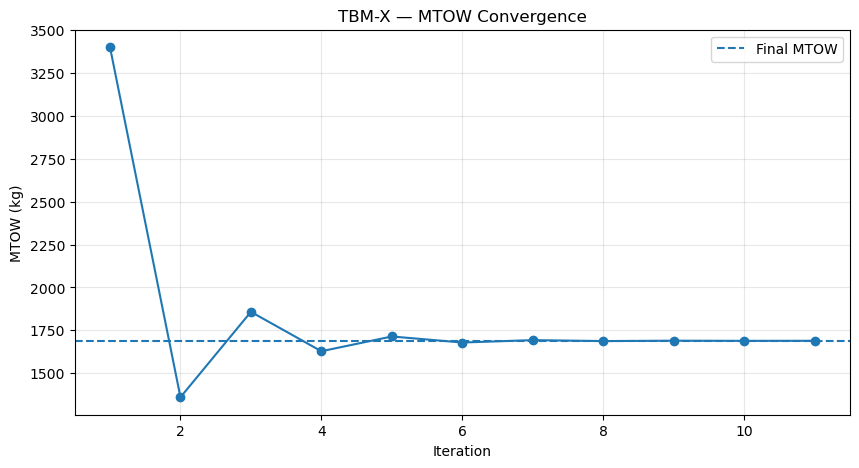

In [34]:
# ============================================================
# MTOW CONVERGENCE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    iteration_history["Iteration"],
    iteration_history["MTOW_kg"],
    marker="o",
)

plt.axhline(
    final_mtow,
    linestyle="--",
    label="Final MTOW"
)

plt.xlabel("Iteration")
plt.ylabel("MTOW (kg)")
plt.title("TBM-X — MTOW Convergence")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**FUEL FRACTION CONVERGENCE**

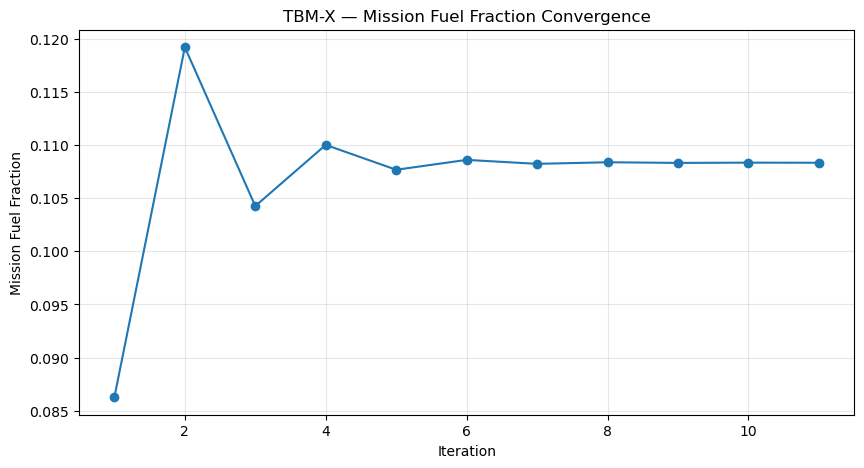

In [36]:
# ============================================================
# FUEL FRACTION CONVERGENCE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    iteration_history["Iteration"],
    iteration_history["Fuel_Fraction"],
    marker="o",
)

plt.xlabel("Iteration")
plt.ylabel("Mission Fuel Fraction")
plt.title("TBM-X — Mission Fuel Fraction Convergence")

plt.grid(True, alpha=0.3)

plt.show()

**L/D EVOLUTION**

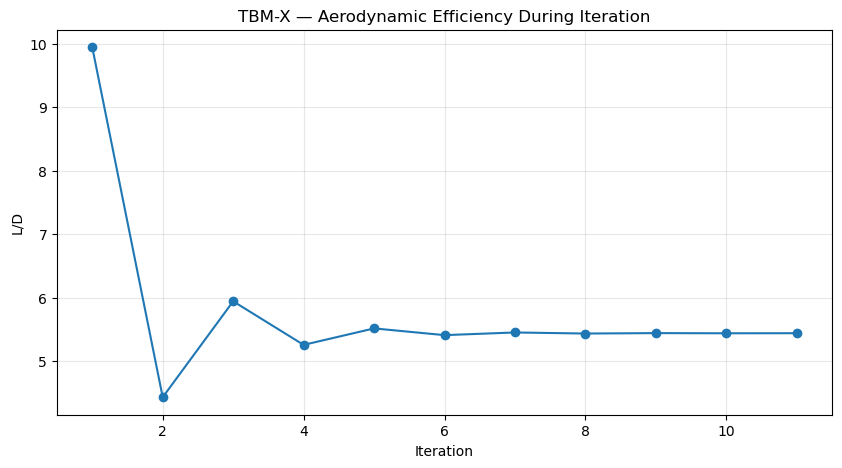

In [37]:
# ============================================================
# L/D EVOLUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    iteration_history["Iteration"],
    iteration_history["L_D"],
    marker="o",
)

plt.xlabel("Iteration")
plt.ylabel("L/D")
plt.title("TBM-X — Aerodynamic Efficiency During Iteration")

plt.grid(True, alpha=0.3)

plt.show()

**CL EVOLUTION**

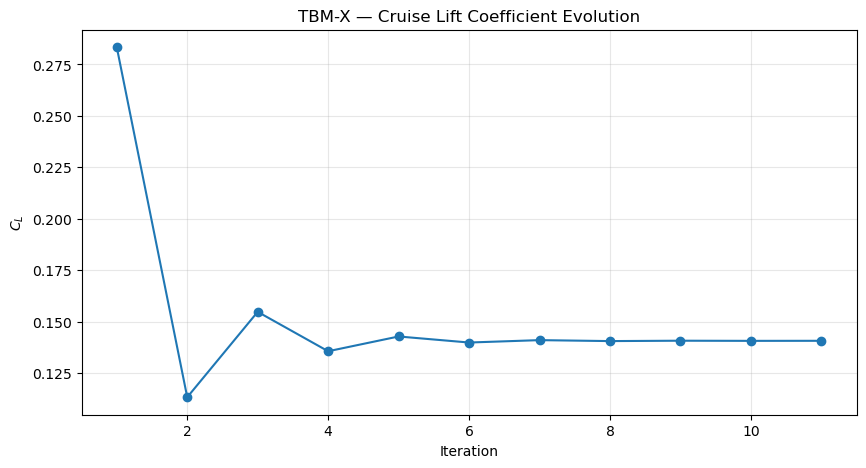

In [38]:
# ============================================================
# CL EVOLUTION
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    iteration_history["Iteration"],
    iteration_history["CL"],
    marker="o",
)

plt.xlabel("Iteration")
plt.ylabel("$C_L$")
plt.title("TBM-X — Cruise Lift Coefficient Evolution")

plt.grid(True, alpha=0.3)

plt.show()

**RELATIVE ERROR**

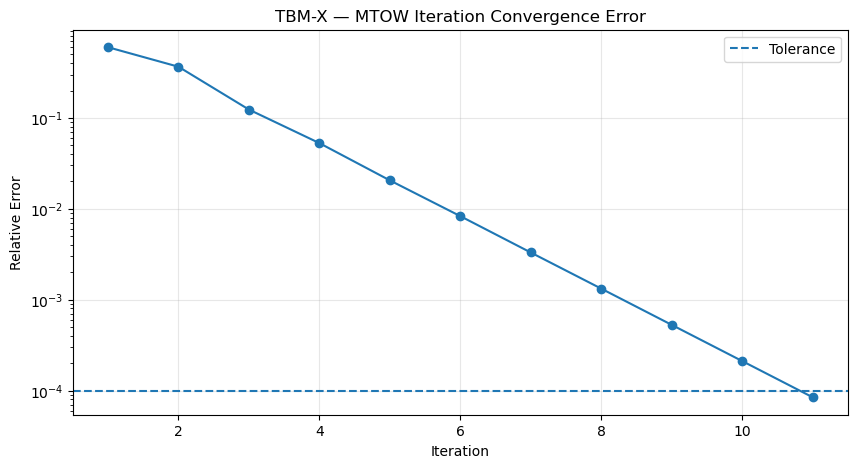

In [39]:
# ============================================================
# CONVERGENCE ERROR
# ============================================================

plt.figure(figsize=(10, 5))

plt.semilogy(
    iteration_history["Iteration"],
    iteration_history["Relative_Error"],
    marker="o",
)

plt.axhline(
    TOLERANCE,
    linestyle="--",
    label="Tolerance"
)

plt.xlabel("Iteration")
plt.ylabel("Relative Error")
plt.title("TBM-X — MTOW Iteration Convergence Error")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

**CONVERGENCE DIAGNOSTICS**

In [40]:
# ============================================================
# CONVERGENCE DIAGNOSTICS
# ============================================================

print("==============================================")
print("TBM-X WEIGHT ↔ MISSION ITERATION DIAGNOSTICS")
print("==============================================")

print(f"Status               : {convergence_status}")
print(f"Iterations           : {len(iteration_history)}")
print(f"Initial MTOW         : {requirements['initial_mtow_kg']:.2f} kg")
print(f"Final MTOW           : {final_mtow:.2f} kg")
print(f"Final relative error : {final_iteration['Relative_Error']:.6e}")
print(f"Fuel fraction        : {final_fuel_fraction:.4f}")
print(f"Empty weight frac.   : {final_empty_fraction:.4f}")
print(f"CL                   : {final_iteration['CL']:.4f}")
print(f"CD                   : {final_iteration['CD']:.4f}")
print(f"L/D                  : {final_iteration['L_D']:.2f}")

print("==============================================")

TBM-X WEIGHT ↔ MISSION ITERATION DIAGNOSTICS
Status               : CONVERGED
Iterations           : 11
Initial MTOW         : 3400.00 kg
Final MTOW           : 1688.98 kg
Final relative error : 8.443730e-05
Fuel fraction        : 0.1083
Empty weight frac.   : 0.5372
CL                   : 0.1408
CD                   : 0.0259
L/D                  : 5.44


**ENGINEERING SANITY CHECKS**

In [41]:
# ============================================================
# ENGINEERING SANITY CHECKS
# ============================================================

diagnostics = []

# ------------------------------------------------------------
# MTOW
# ------------------------------------------------------------

if final_mtow < 2000:
    diagnostics.append(
        "WARNING: MTOW is unusually low for the target class."
    )

elif final_mtow > 6000:
    diagnostics.append(
        "WARNING: MTOW is unusually high for the target class."
    )

else:
    diagnostics.append(
        "MTOW is within a broad conceptual range."
    )


# ------------------------------------------------------------
# CL
# ------------------------------------------------------------

if final_iteration["CL"] < 0.2:
    diagnostics.append(
        "WARNING: Cruise CL is unusually low."
    )

elif final_iteration["CL"] > 1.0:
    diagnostics.append(
        "WARNING: Cruise CL is unusually high."
    )

else:
    diagnostics.append(
        "Cruise CL is within a plausible conceptual range."
    )


# ------------------------------------------------------------
# L/D
# ------------------------------------------------------------

if final_iteration["L_D"] < 8:
    diagnostics.append(
        "WARNING: L/D is low for a high-performance turboprop concept."
    )

elif final_iteration["L_D"] > 25:
    diagnostics.append(
        "WARNING: L/D is unusually high; check assumptions."
    )

else:
    diagnostics.append(
        "L/D is within a plausible conceptual range."
    )


for message in diagnostics:
    print("-", message)

- WARNING: MTOW is unusually low for the target class.
- WARNING: Cruise CL is unusually low.
- WARNING: L/D is low for a high-performance turboprop concept.


In [46]:
import sys
from pathlib import Path
current_dir=Path.cwd()

**BENCHMARK COMPARISON**

In [47]:
# ============================================================
# BENCHMARK COMPARISON
# ============================================================

benchmark_candidates = [
    current_dir / "../03_benchmark_database/TBM_X_Master_v0_2.csv",
    current_dir / "../data/processed/TBM_X_Master_v0_2.csv",
    current_dir / "data/processed/TBM_X_Master_v0_2.csv",
]

benchmark_path = None

for candidate in benchmark_candidates:

    candidate = candidate.resolve()

    if candidate.exists():
        benchmark_path = candidate
        break

if benchmark_path is not None:

    benchmark_df = pd.read_csv(
        benchmark_path
    )

    print("Benchmark file found:")
    print(benchmark_path)

else:

    benchmark_df = None

    print(
        "Benchmark file was not found from the current "
        "working directory."
    )

Benchmark file found:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\data\processed\TBM_X_Master_v0_2.csv


**BENCHMARK STRUCTURE CHECK**

In [48]:
# ============================================================
# BENCHMARK STRUCTURE
# ============================================================

if benchmark_df is not None:

    print("Shape:", benchmark_df.shape)

    display(
        benchmark_df.head()
    )

Shape: (5, 35)


,aircraft_id,manufacturer,variant,family,status,confidence,requirement_flag,MRW_kg,MTOW_kg,MZFW_kg,...,takeoff_power_kW,usable_fuel_L,wing_area_m2,wing_loading_kg_m2,power_to_weight_kW_kg,kg_per_kW,aspect_ratio,empty_weight_fraction,fuel_volume_L_per_MTOW_kg,nominal_cruise_time_h
0,TBM960,Daher,TBM 960,TBM,reported,A,validation_reference,3470.0,3454.000000,2836.0,...,667.401385,1106.000000,18.0,191.888889,0.193226,5.175296,9.144939,0.631152,0.320208,4.803030
1,TBM910,Daher,TBM 910,TBM,reported,B,validation_reference,NaN,3353.861984,NaN,...,633.844891,1101.554829,NaN,NaN,0.188990,5.291298,NaN,0.626048,0.328444,NaN
2,TBM940,Daher,TBM 940,TBM,reported,B,validation_reference,NaN,3354.000000,NaN,...,633.844891,1101.554829,NaN,NaN,0.188982,5.291515,NaN,0.625224,0.328430,NaN
3,PC12NGX,Pilatus,PC-12 NGX,PC12,reported,A,validation_reference,NaN,4740.040267,NaN,...,NaN,1521.735537,NaN,NaN,NaN,NaN,NaN,NaN,0.321039,6.217241
4,M600SLS,Piper,M600/SLS,M600,reported,A,validation_reference,NaN,2721.554220,NaN,...,447.419923,984.207064,NaN,NaN,0.164399,6.082774,NaN,0.608333,0.361634,6.051095


**TBM BENCHMARK MTOW**

In [49]:
# ============================================================
# TBM BENCHMARK MTOW
# ============================================================

if benchmark_df is not None:

    tbm_benchmark = benchmark_df[
        benchmark_df["aircraft_id"].str.contains(
            "TBM",
            case=False,
            na=False
        )
    ].copy()

    if "MTOW_kg" in tbm_benchmark.columns:

        print(
            tbm_benchmark[
                ["aircraft_id", "MTOW_kg"]
            ]
        )

    else:

        print(
            "MTOW_kg column not found."
        )

  aircraft_id      MTOW_kg
0      TBM960  3454.000000
1      TBM910  3353.861984
2      TBM940  3354.000000


**TBM-X vs TBM BENCHMARK**

In [50]:
# ============================================================
# TBM-X vs TBM BENCHMARK
# ============================================================

if benchmark_df is not None and "MTOW_kg" in benchmark_df.columns:

    benchmark_mtow = tbm_benchmark[
        "MTOW_kg"
    ].dropna()

    if len(benchmark_mtow) > 0:

        benchmark_mean_mtow = benchmark_mtow.mean()

        mtow_difference_percent = (
            (
                final_mtow
                - benchmark_mean_mtow
            )
            / benchmark_mean_mtow
            * 100
        )

        print(
            f"TBM-X MTOW              : {final_mtow:.1f} kg"
        )

        print(
            f"TBM benchmark mean MTOW : "
            f"{benchmark_mean_mtow:.1f} kg"
        )

        print(
            f"Difference               : "
            f"{mtow_difference_percent:.1f}%"
        )

TBM-X MTOW              : 1689.0 kg
TBM benchmark mean MTOW : 3387.3 kg
Difference               : -50.1%


**TBM-X vs BENCHMARK MTOW**

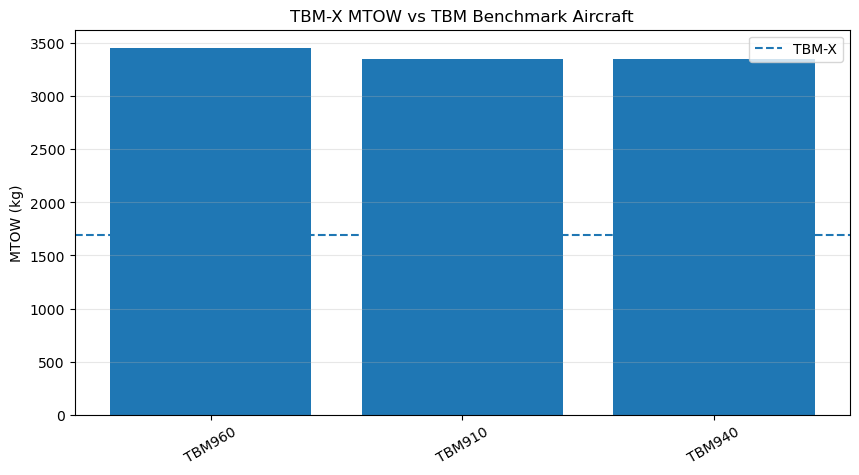

In [51]:
# ============================================================
# TBM-X vs BENCHMARK MTOW
# ============================================================

if benchmark_df is not None and "MTOW_kg" in benchmark_df.columns:

    plot_df = tbm_benchmark[
        ["aircraft_id", "MTOW_kg"]
    ].dropna()

    if len(plot_df) > 0:

        plt.figure(figsize=(10, 5))

        plt.bar(
            plot_df["aircraft_id"],
            plot_df["MTOW_kg"],
        )

        plt.axhline(
            final_mtow,
            linestyle="--",
            label="TBM-X"
        )

        plt.ylabel("MTOW (kg)")
        plt.title(
            "TBM-X MTOW vs TBM Benchmark Aircraft"
        )

        plt.xticks(rotation=30)
        plt.grid(
            axis="y",
            alpha=0.3
        )

        plt.legend()

        plt.show()

**TBM-X DESIGN SNAPSHOT**

In [52]:
# ============================================================
# TBM-X DESIGN SNAPSHOT
# ============================================================

tbmx_snapshot = pd.Series({
    "Aircraft Category":
        requirements["aircraft_category"],

    "MTOW (kg)":
        final_mtow,

    "Wing Area (m²)":
        geometry["wing_area_m2"],

    "Cruise Speed (kt)":
        requirements["cruise_speed_kt"],

    "Cruise Altitude (ft)":
        requirements["cruise_altitude_ft"],

    "Range (km)":
        requirements["range_km"],

    "Cruise CL":
        final_iteration["CL"],

    "Cruise CD":
        final_iteration["CD"],

    "L/D":
        final_iteration["L_D"],

    "Mission Fuel Fraction":
        final_fuel_fraction,

    "Empty Weight Fraction":
        final_empty_fraction,

    "Convergence":
        convergence_status,
})

tbmx_snapshot

Aircraft Category        Single Engine Turboprop
MTOW (kg)                            1688.980021
Wing Area (m²)                              18.0
Cruise Speed (kt)                            300
Cruise Altitude (ft)                       25000
Range (km)                                  3000
Cruise CL                               0.140764
Cruise CD                               0.025862
L/D                                     5.442962
Mission Fuel Fraction                   0.108341
Empty Weight Fraction                   0.537196
Convergence                            CONVERGED
dtype: object

**SAVE ITERATION RESULTS**

In [53]:
# ============================================================
# SAVE ITERATION RESULTS
# ============================================================

output_dir = current_dir / "outputs"

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

iteration_output_path = (
    output_dir
    / "TBM_X_weight_mission_iteration.csv"
)

iteration_history.to_csv(
    iteration_output_path,
    index=False
)

print(
    "Iteration history saved to:"
)

print(
    iteration_output_path.resolve()
)

Iteration history saved to:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\TBM_X_weight_mission_iteration.csv


**SAVE FINAL DESIGN SNAPSHOT**

In [54]:
# ============================================================
# SAVE FINAL DESIGN SNAPSHOT
# ============================================================

snapshot_output_path = (
    output_dir
    / "TBM_X_design_snapshot.csv"
)

tbmx_snapshot.to_csv(
    snapshot_output_path,
    header=["Value"]
)

print(
    "Design snapshot saved to:"
)

print(
    snapshot_output_path.resolve()
)

Design snapshot saved to:
C:\Users\musta\Documents\RAYMER\TBM-X_v0.2_data_engineering\outputs\TBM_X_design_snapshot.csv


**FINAL ENGINEERING SUMMARY**

In [55]:
# ============================================================
# FINAL ENGINEERING SUMMARY
# ============================================================

print("""
============================================================
TBM-X — WEIGHT ↔ MISSION ITERATION
============================================================

This notebook established the first coupled TBM-X loop:

    Weight Sizing
          ↕
       Mission
          ↕
    Aerodynamics
          ↕
      Fuel Mass

The benchmark database is used for validation,
not for forcing the design toward a predefined answer.

IMPORTANT:
The current model still contains conceptual engineering
assumptions for:
    - CD0
    - Oswald efficiency
    - propeller efficiency
    - BSFC
    - empty-weight estimation
    - mission segment fractions

These assumptions must be progressively replaced or
calibrated using higher-fidelity physics and benchmark data.

Next major step:
    06 — RAYMER GEOMETRY SIZING

============================================================
""")


TBM-X — WEIGHT ↔ MISSION ITERATION

This notebook established the first coupled TBM-X loop:

    Weight Sizing
          ↕
       Mission
          ↕
    Aerodynamics
          ↕
      Fuel Mass

The benchmark database is used for validation,
not for forcing the design toward a predefined answer.

IMPORTANT:
The current model still contains conceptual engineering
assumptions for:
    - CD0
    - Oswald efficiency
    - propeller efficiency
    - BSFC
    - empty-weight estimation
    - mission segment fractions

These assumptions must be progressively replaced or
calibrated using higher-fidelity physics and benchmark data.

Next major step:
    06 — RAYMER GEOMETRY SIZING


